In [11]:
import json
from pathlib import Path
import pandas as pd
import seaborn as sns

results_dir = '/projectnb/vkolagrp/bellitti/adrd-foundation-model/adrd_simplified_evaluation/results_sub'

data = []
for f in Path(results_dir).rglob('metrics.json'):
    with open(f) as file:
        data.append(json.load(file))

summary = pd.concat([pd.DataFrame(f) for f in data]).set_index(['benchmark_name','model']).sort_index()

In [12]:
summary.columns.name = 'metric'

tall = summary.stack()
tall.name = 'value'

tall = tall.to_frame().reset_index()

In [13]:
tall

,benchmark_name,model,metric,value
0,medexpqa,Qwen3-4B,accuracy,0.685950
1,medexpqa,Qwen3-4B,balanced_accuracy,0.664561
2,medexpqa,Qwen3-4B,precision_macro,0.662352
3,medexpqa,Qwen3-4B,recall_macro,0.664561
4,medexpqa,Qwen3-4B,f1_macro,0.662921
...,...,...,...,...
115,medqa_test,Qwen3-4B,recall_macro,0.683397
116,medqa_test,Qwen3-4B,f1_macro,0.684021
117,medqa_test,Qwen3-4B,precision_weighted,0.690774
118,medqa_test,Qwen3-4B,recall_weighted,0.687000


In [14]:
sns.set_style('darkgrid')

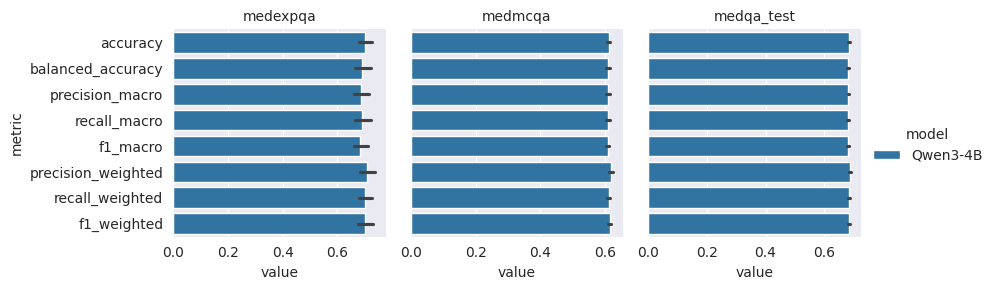

In [17]:
g = sns.catplot(
    tall,
    y="metric",
    x="value",
    col="benchmark_name",
    hue="model",
    sharex=False,
    # col_wrap=2,
    height=3,
    kind='bar'
)

g.set_titles(col_template="{col_name}")

# g.set(xlim=(0,1))

notice that we can read the configuration (e.g. temperature) from `config.yml` for each of these, so we know if it makes sense to average